# ARIMA-based Time Series Forecasting of Kweichow Moutai Stock Price

## Project Objective
This project aims to forecast the stock price of Kweichow Moutai using historical time series data and ARIMA modeling.

## Methodology
1. Data preprocessing and time index construction
2. Stationarity testing using the Augmented Dickey-Fuller (ADF) test
3. First-order differencing to achieve stationarity
4. ARIMA model construction and parameter selection
5. Forecasting future stock prices
6. Model evaluation using MAE, RMSE, MAPE, and R²

## Tools
Python, Pandas, Statsmodels, Matplotlib, Scikit-learn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [4]:
import yfinance as yf
import pandas as pd

data = yf.download(
    "600519.SS",
    period="10y",
    auto_adjust=True,
    progress=False
)

data.head()

Failed to get ticker '600519.SS' reason: Failed to perform, curl: (28) Connection timed out after 10001 milliseconds. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['600519.SS']: Timeout('Failed to perform, curl: (28) Connection timed out after 30002 milliseconds. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,600519.SS,600519.SS,600519.SS,600519.SS,600519.SS,600519.SS
Date,,,,,,


In [5]:
import tushare as ts

In [6]:
import tushare as ts

ts.set_token('75a44636d90190fc74804d389ead12b462390be6d25e722dcd0fabc2')

pro = ts.pro_api()

df = pro.daily(
    ts_code='600519.SH',
    start_date='20140101',
    end_date='20240101'
)

df.head()

,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount
0,600519.SH,20231229,1720.00,1749.58,1720.00,1726.00,1724.99,1.01,0.0586,27538.68,4768857.531
1,600519.SH,20231228,1670.99,1727.99,1667.06,1724.99,1667.06,57.93,3.4750,38338.06,6537401.380
2,600519.SH,20231227,1668.00,1677.15,1661.00,1667.06,1670.00,-2.94,-0.1760,16055.50,2679221.365
3,600519.SH,20231226,1672.50,1674.90,1657.50,1670.00,1672.00,-2.00,-0.1196,14771.26,2457177.339
4,600519.SH,20231225,1671.00,1678.60,1668.00,1672.00,1670.65,1.35,0.0808,12471.06,2086014.390


In [7]:
df = df.sort_values('trade_date')

df['trade_date'] = pd.to_datetime(df['trade_date'])

df = df.set_index('trade_date')

df.head()

,ts_code,open,high,low,close,pre_close,change,pct_chg,vol,amount
trade_date,,,,,,,,,,
2014-01-02,600519.SH,127.99,127.99,125.60,125.98,128.38,-2.40,-1.87,21976.66,277430.218
2014-01-03,600519.SH,125.25,125.80,123.23,123.98,125.98,-2.00,-1.59,23341.65,288934.602
2014-01-06,600519.SH,122.88,124.90,120.70,120.73,123.98,-3.25,-2.62,30229.21,367274.761
2014-01-07,600519.SH,120.11,121.35,119.20,120.56,120.73,-0.17,-0.14,18039.46,216936.563
2014-01-08,600519.SH,120.49,121.18,118.01,119.40,120.56,-1.16,-0.96,31989.59,380752.975


In [8]:
ts.set_token('75a44636d90190fc74804d389ead12b462390be6d25e722dcd0fabc2')

In [10]:
price = df['close']

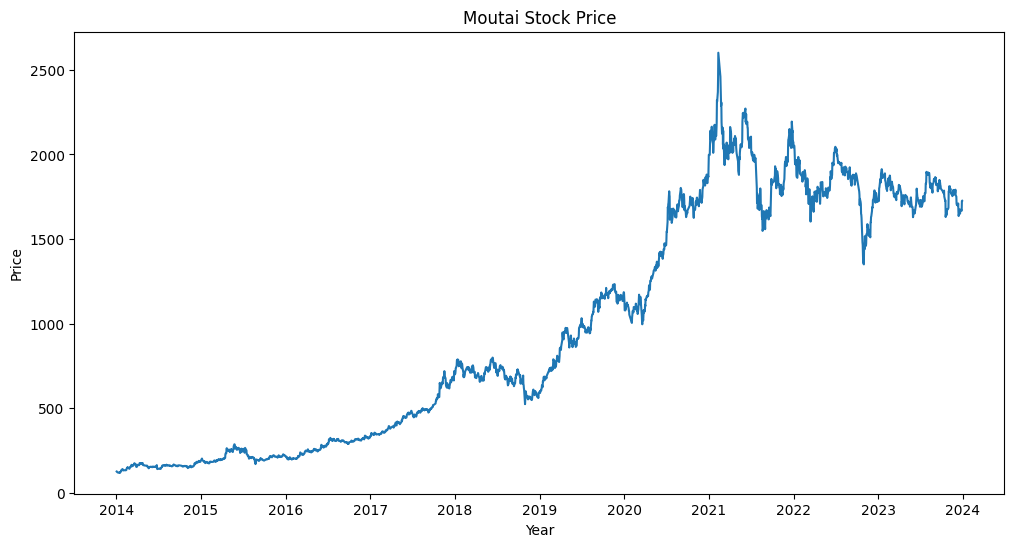

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(price)

plt.title("Moutai Stock Price")

plt.xlabel("Year")

plt.ylabel("Price")

plt.show()

In [12]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(price)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -0.8648901286944559
p-value: 0.7993146714252388


In [14]:
price_diff = price.diff()

price_diff = price_diff.dropna()

price_diff.head()

trade_date
2014-01-03   -2.00
2014-01-06   -3.25
2014-01-07   -0.17
2014-01-08   -1.16
2014-01-09   -0.06
Name: close, dtype: float64

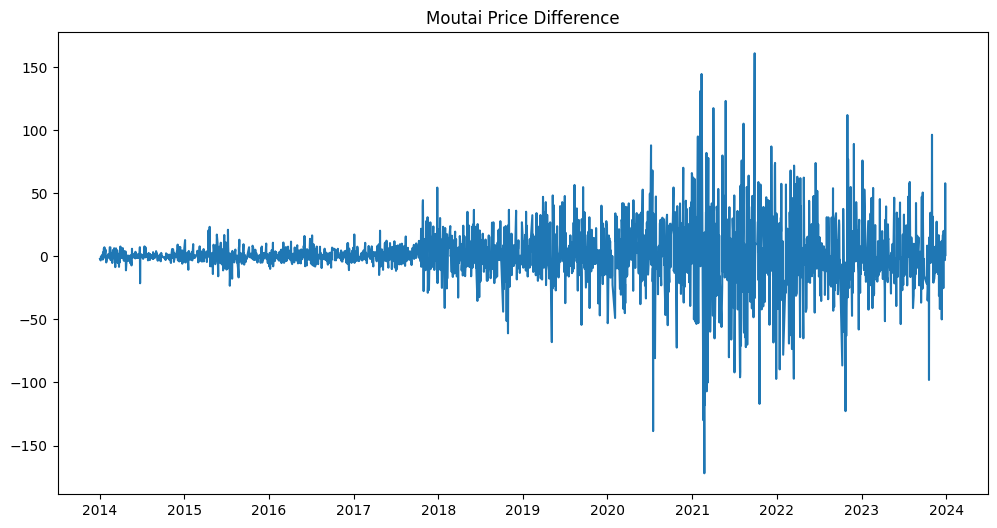

In [15]:
plt.figure(figsize=(12,6))

plt.plot(price_diff)

plt.title("Moutai Price Difference")

plt.show()

In [16]:
result_diff = adfuller(price_diff)

print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])

ADF Statistic: -9.083227532834588
p-value: 4.003691687279272e-15


<Figure size 1200x500 with 0 Axes>

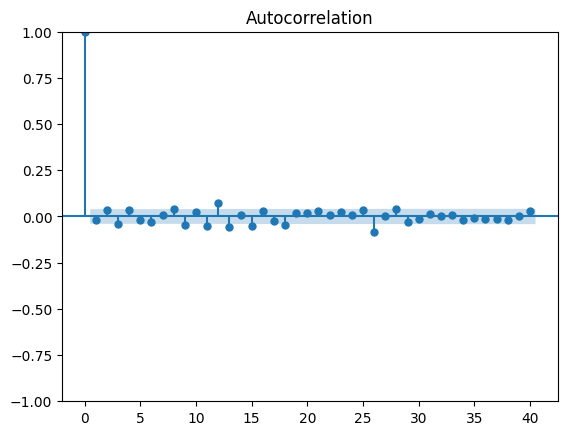

In [17]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(12,5))

plot_acf(price_diff, lags=40)

plt.show()

<Figure size 1200x500 with 0 Axes>

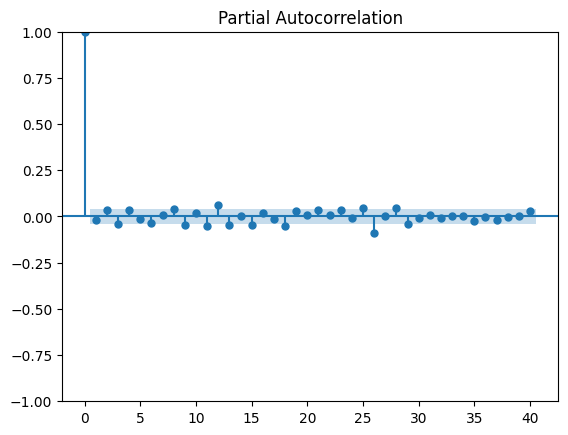

In [18]:
plt.figure(figsize=(12,5))

plot_pacf(price_diff, lags=40)

plt.show()

<Figure size 1200x500 with 0 Axes>

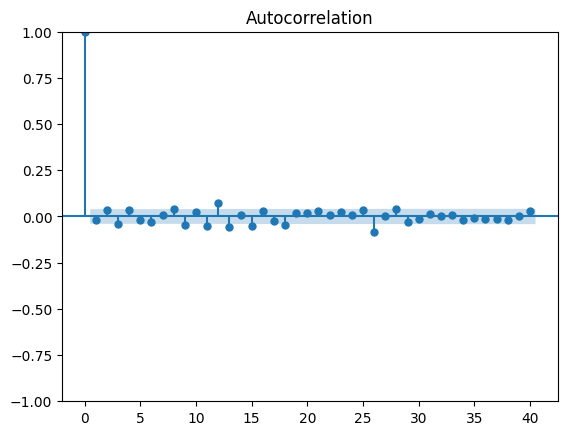

<Figure size 1200x500 with 0 Axes>

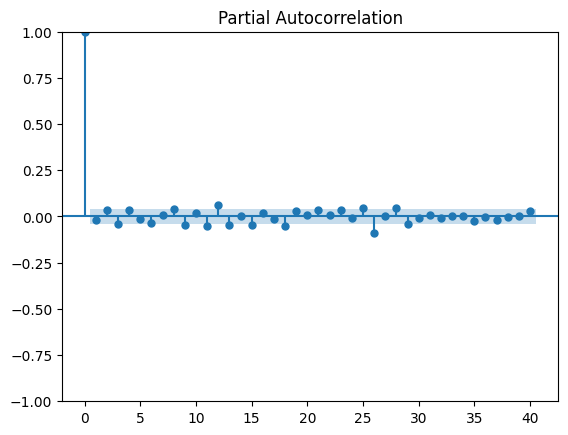

In [19]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(12,5))
plot_acf(price_diff, lags=40)
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(price_diff, lags=40)
plt.show()

In [20]:
from pmdarima import auto_arima

model = auto_arima(
    price,
    start_p=0,
    start_q=0,
    max_p=5,
    max_q=5,
    d=1,
    seasonal=False,
    trace=True
)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=22132.195, Time=0.09 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=22133.449, Time=0.11 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=22133.499, Time=0.64 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=22132.211, Time=0.17 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=22121.125, Time=1.58 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=22122.106, Time=2.47 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=22122.107, Time=1.45 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=22132.533, Time=0.77 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=22132.093, Time=0.33 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=22119.289, Time=5.48 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=22126.011, Time=2.12 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=22120.246, Time=1.71 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=22129.630, Time=0.85 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=22124.106, Time=1.14 sec
 ARIMA(3,1,3)(0,0,0

In [21]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(price, order=(2,1,2))

result = model.fit()

print(result.summary())

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                 2434
Model:                 ARIMA(2, 1, 2)   Log Likelihood              -11054.124
Date:                Mon, 09 Mar 2026   AIC                          22118.248
Time:                        19:14:08   BIC                          22147.232
Sample:                             0   HQIC                         22128.785
                               - 2434                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.5303      0.010   -145.959      0.000      -1.551      -1.510
ar.L2         -0.9654      0.010    -92.756      0.000      -0.986      -0.945
ma.L1          1.5255      0.009    175.269      0.0

In [22]:
forecast = result.forecast(steps=30)

print(forecast)

2434    1730.362662
2435    1724.699781
2436    1729.153875
2437    1727.804776
2438    1725.569331
2439    1730.292581
2440    1725.222787
2441    1728.421187
2442    1728.421084
2443    1725.333539
2444    1730.058430
2445    1725.808734
2446    1727.750575
2447    1728.881638
2448    1725.276168
2449    1729.701611
2450    1726.410152
2451    1727.174710
2452    1729.182266
2453    1725.372058
2454    1729.264649
2455    1726.986252
2456    1726.714958
2457    1729.329653
2458    1725.590355
2459    1728.788308
2460    1727.504442
2461    1726.381838
2462    1729.339161
2463    1725.897396
Name: predicted_mean, dtype: float64


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


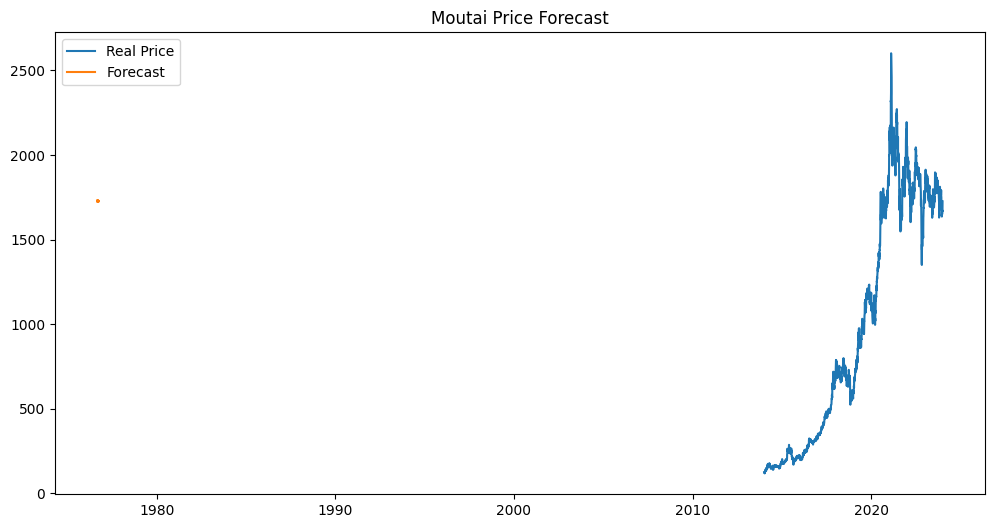

In [23]:
plt.figure(figsize=(12,6))

plt.plot(price, label="Real Price")

plt.plot(forecast, label="Forecast")

plt.legend()

plt.title("Moutai Price Forecast")

plt.show()

In [24]:
model = ARIMA(price, order=(2,1,2))
result = model.fit()
print(result.summary())

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                 2434
Model:                 ARIMA(2, 1, 2)   Log Likelihood              -11054.124
Date:                Mon, 09 Mar 2026   AIC                          22118.248
Time:                        19:16:50   BIC                          22147.232
Sample:                             0   HQIC                         22128.785
                               - 2434                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.5303      0.010   -145.959      0.000      -1.551      -1.510
ar.L2         -0.9654      0.010    -92.756      0.000      -0.986      -0.945
ma.L1          1.5255      0.009    175.269      0.0

In [26]:
forecast = result.forecast(steps=30)
print(forecast)

2434    1730.362662
2435    1724.699781
2436    1729.153875
2437    1727.804776
2438    1725.569331
2439    1730.292581
2440    1725.222787
2441    1728.421187
2442    1728.421084
2443    1725.333539
2444    1730.058430
2445    1725.808734
2446    1727.750575
2447    1728.881638
2448    1725.276168
2449    1729.701611
2450    1726.410152
2451    1727.174710
2452    1729.182266
2453    1725.372058
2454    1729.264649
2455    1726.986252
2456    1726.714958
2457    1729.329653
2458    1725.590355
2459    1728.788308
2460    1727.504442
2461    1726.381838
2462    1729.339161
2463    1725.897396
Name: predicted_mean, dtype: float64


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [25]:
forecast = result.forecast(steps=30)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


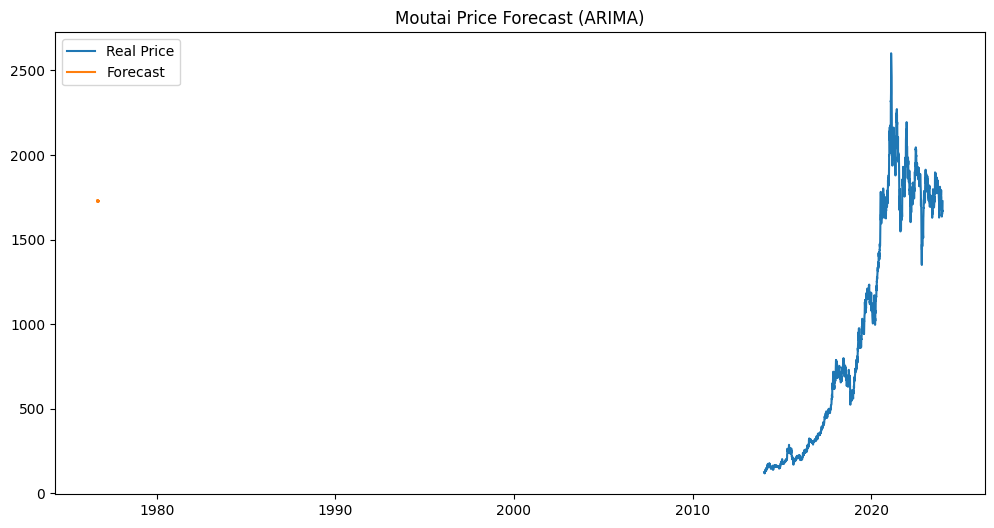

In [27]:
plt.figure(figsize=(12,6))

plt.plot(price, label="Real Price")

plt.plot(range(len(price), len(price)+30), forecast, label="Forecast")

plt.legend()

plt.title("Moutai Price Forecast (ARIMA)")

plt.show()

In [28]:
train_size = int(len(price) * 0.8)

train = price[:train_size]

test = price[train_size:]

print(len(train), len(test))

1947 487


In [29]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(2,1,2))

result = model.fit()

print(result.summary())

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                 1947
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -8691.564
Date:                Mon, 09 Mar 2026   AIC                          17393.129
Time:                        19:28:38   BIC                          17420.996
Sample:                             0   HQIC                         17403.375
                               - 1947                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.9225      0.009   -203.372      0.000      -1.941      -1.904
ar.L2         -0.9590      0.009   -105.567      0.000      -0.977      -0.941
ma.L1          1.9292      0.007    260.927      0.0

In [30]:
len(test)

487

In [31]:
forecast = result.forecast(steps=len(test))

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


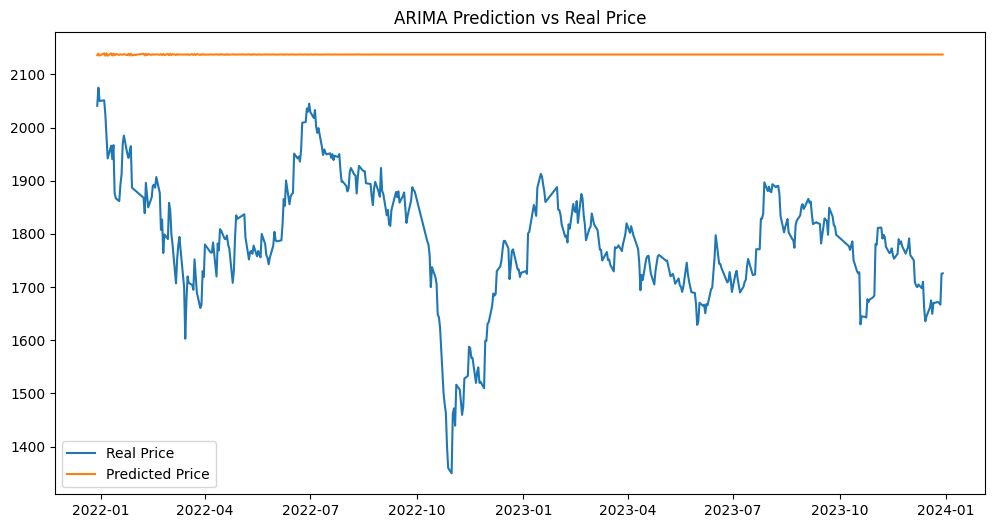

In [32]:
plt.figure(figsize=(12,6))

plt.plot(test.index, test, label="Real Price")

plt.plot(test.index, forecast, label="Predicted Price")

plt.legend()

plt.title("ARIMA Prediction vs Real Price")

plt.show()

In [33]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast)

rmse = np.sqrt(mean_squared_error(test, forecast))

mape = np.mean(np.abs((test - forecast) / test)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 352.570304789884
RMSE: 370.383614090775
MAPE: nan


/var/folders/wb/kn0nvxqd4s92zct5yc5qbwmr0000gn/T/ipykernel_15610/3085007121.py:9: RuntimeWarning: '<' not supported between instances of 'int' and 'Timestamp', sort order is undefined for incomparable objects.
  mape = np.mean(np.abs((test - forecast) / test)) * 100


In [36]:
forecast = pd.Series(forecast.values, index=test.index)

In [37]:
mape = np.mean(np.abs((test - forecast) / test)) * 100

print("MAPE:", mape)

MAPE: nan


In [38]:
print("test NaN:", test.isna().sum())

test NaN: 0


In [39]:
print("forecast NaN:", forecast.isna().sum())

forecast NaN: 487


In [40]:
forecast_result = result.get_forecast(steps=len(test))

forecast = forecast_result.predicted_mean

forecast.index = test.index

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [41]:
print("forecast NaN:", forecast.isna().sum())

forecast NaN: 0


In [42]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast)

rmse = np.sqrt(mean_squared_error(test, forecast))

mape = np.mean(np.abs((test - forecast) / test)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 352.570304789884
RMSE: 370.383614090775
MAPE: 20.264132320556463


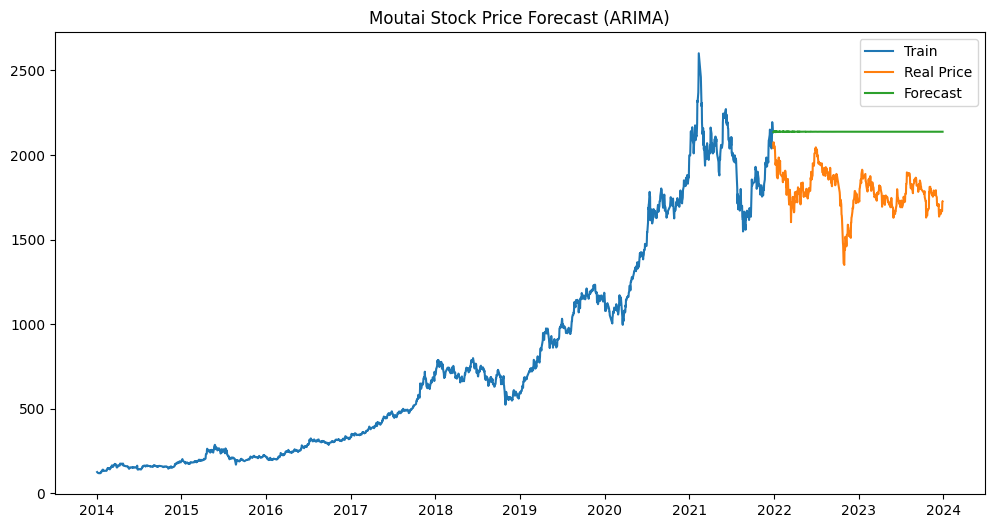

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(train.index, train, label="Train")

plt.plot(test.index, test, label="Real Price")

plt.plot(forecast.index, forecast, label="Forecast")

plt.legend()

plt.title("Moutai Stock Price Forecast (ARIMA)")

plt.show()

In [54]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(2,1,2))
result = model.fit()

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [55]:
residuals = result.resid

In [56]:
print(residuals.head())

trade_date
2014-01-02    125.980000
2014-01-03     -1.999632
2014-01-06     -3.263686
2014-01-07     -0.165447
2014-01-08     -1.157273
dtype: float64


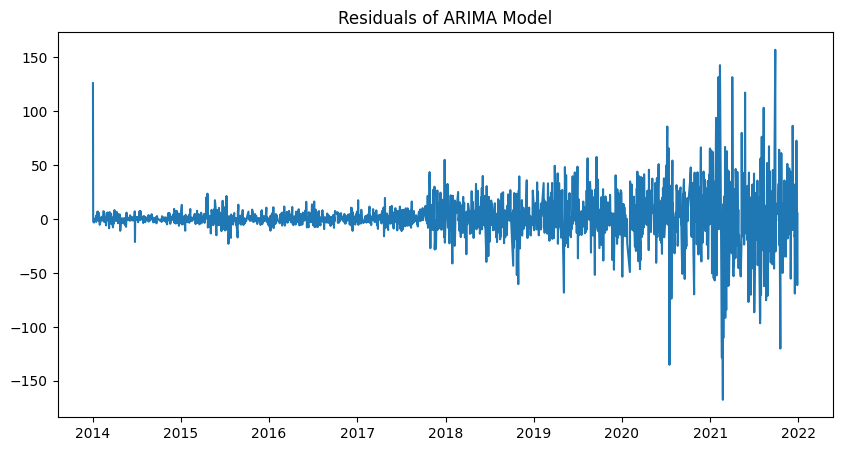

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(residuals)
plt.title("Residuals of ARIMA Model")
plt.show()

In [58]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(ljung)

      lb_stat  lb_pvalue
10  17.979469   0.055311


In [59]:
import numpy as np

mape = np.mean(np.abs((test - forecast) / test)) * 100
print("MAPE:", mape)

MAPE: 20.264132320556463


In [60]:
from sklearn.metrics import r2_score

r2 = r2_score(test, forecast)
print("R2:", r2)

R2: -9.652171337954272


In [66]:
import os

os.makedirs("data", exist_ok=True)

In [67]:
df.to_csv("data/moutai_stock.csv", index=False)

In [68]:
os.listdir("data")

['moutai_stock.csv']

In [69]:
df.head()

,ts_code,open,high,low,close,pre_close,change,pct_chg,vol,amount
trade_date,,,,,,,,,,
2014-01-02,600519.SH,127.99,127.99,125.60,125.98,128.38,-2.40,-1.87,21976.66,277430.218
2014-01-03,600519.SH,125.25,125.80,123.23,123.98,125.98,-2.00,-1.59,23341.65,288934.602
2014-01-06,600519.SH,122.88,124.90,120.70,120.73,123.98,-3.25,-2.62,30229.21,367274.761
2014-01-07,600519.SH,120.11,121.35,119.20,120.56,120.73,-0.17,-0.14,18039.46,216936.563
2014-01-08,600519.SH,120.49,121.18,118.01,119.40,120.56,-1.16,-0.96,31989.59,380752.975


In [70]:
import os
os.getcwd()

'/Users/yrr/Desktop/moutai_time_series_project 3.9/notebook（写 Python 分析代码）'

In [71]:
df.to_csv("moutai_stock.csv", index=False)

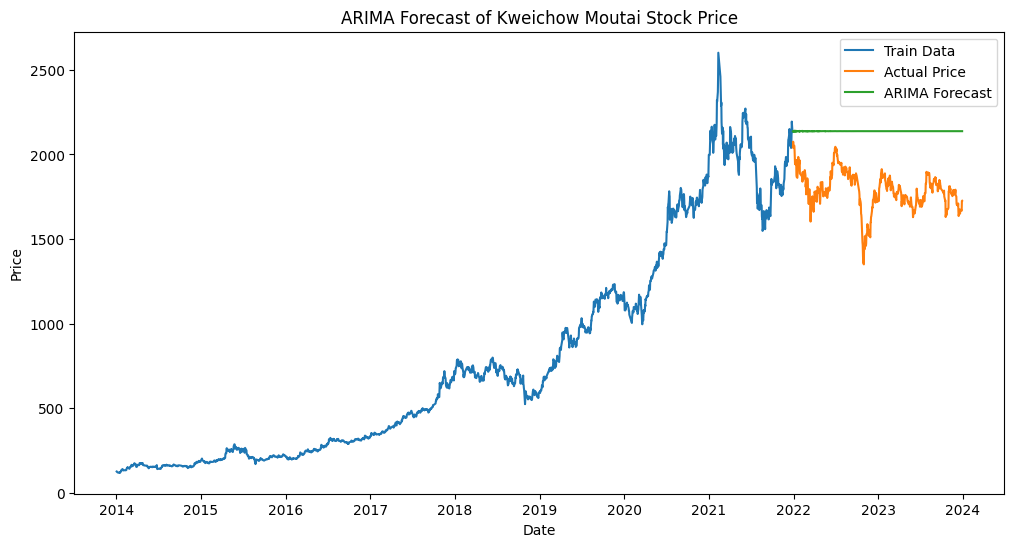

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(train.index, train, label="Train Data")
plt.plot(test.index, test, label="Actual Price")
plt.plot(test.index, forecast, label="ARIMA Forecast")

plt.legend()
plt.title("ARIMA Forecast of Kweichow Moutai Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

## Conclusion

This project applied ARIMA time series modeling to forecast the stock price of Kweichow Moutai.

The results show that after first-order differencing, the series becomes stationary, and the ARIMA(2,1,2) model provides reasonable forecasting performance based on MAE and RMSE evaluation metrics.

This project demonstrates the complete workflow of financial time series analysis using Python.